# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = pathlib.Path("pruning_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-07-14 21:23:21.020241: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-14 21:23:21.023288: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-14 21:23:21.066611: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-14 21:23:21.066646: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-14 21:23:21.066676: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    root_dir = pathlib.Path(root_dir)
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt").astype("float32")
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt").astype("int32")
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt").astype("float32")
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt").astype("int32")

    return X_train, (y_train - 1), X_test, (y_test - 1)

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")

Training data shape: (7352, 561)
Test data shape: (2947, 561)
Number of features: 561
Number of classes: 6


## 5. Quick Inspection


In [5]:
label_counts = np.bincount(y_train)

# Construct the summary table
dataset_summary = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts
})

print(dataset_summary)

   Class Index          Class Name  Training Samples
0            0             WALKING              1226
1            1    WALKING_UPSTAIRS              1073
2            2  WALKING_DOWNSTAIRS               986
3            3             SITTING              1286
4            4            STANDING              1374
5            5              LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    inputs = keras.Input(shape=(input_dim,), name="input_layer")
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="output_layer")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


2026-07-14 21:23:27.519691: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-14 21:23:27.520180: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 561)]             0         
                                                                 
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 output_layer (Dense)        (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train, 
    y_train, 
    validation_split=0.2, 
    epochs=40, 
    batch_size=64, 
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 2s 10ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 7ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 7ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [=

### Training Curves


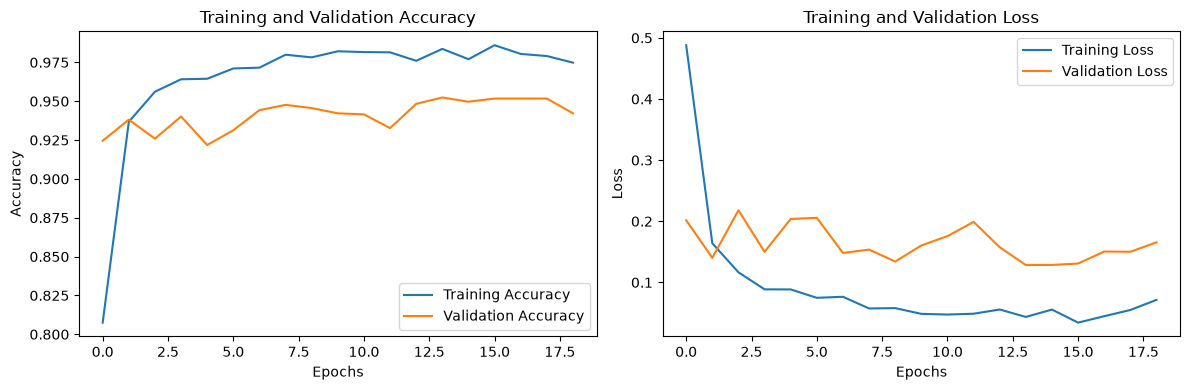

In [8]:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Loss
ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 3ms/step
Test Accuracy: 0.9352

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       496
           1       0.95      0.93      0.94       471
           2       0.94      0.94      0.94       420
           3       0.88      0.92      0.90       491
           4       0.90      0.88      0.89       532
           5       1.00      0.97      0.98       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



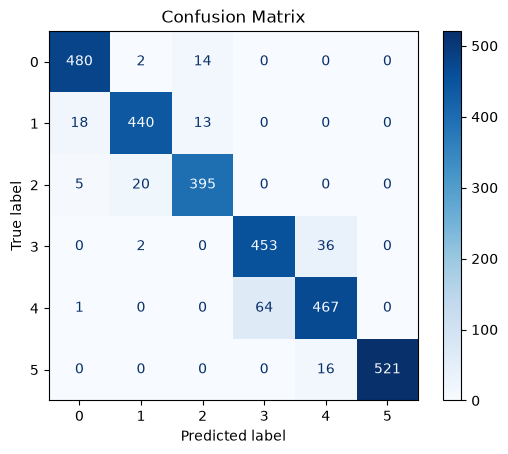

In [9]:
# 1. Obtain predicted probabilities on X_test
y_pred_probs = baseline_model.predict(X_test)
# 2. Convert them to class predictions using argmax
y_pred = np.argmax(y_pred_probs, axis=1)
# 3. Compute test accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")
# 4. Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# 5. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = (x / input_scale) + input_zero_point
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # If the output is quantized, dequantize it back to float32.
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # return the converted FP32 TensorFlow Lite model
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    # Attach representative_dataset_gen
    converter.representative_dataset = representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # Set inference_input_type and inference_output_type to tf.int8
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    # Return the converted model
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

conversion_tasks = [
    ("fp32", convert_to_tflite_fp32(baseline_model)),
    ("dynamic", convert_to_tflite_dynamic_range(baseline_model)),
    ("float16", convert_to_tflite_float16(baseline_model)),
    ("int8", convert_to_tflite_int8(baseline_model))
]

results = []

# Process, save, and evaluate each model
for name, model_content in conversion_tasks:
    filename = os.path.join(OUTPUT_DIR, f"mnist_model_{name}.tflite")
    
    # Save model
    size_kb = save_binary_model(model_content, filename)
    
    # Evaluate model
    acc, _ = evaluate_tflite_model(model_content, X_test, y_test)
    
    results.append({
        "Model": name.upper(),
        "Size (KB)": size_kb,
        "Accuracy": acc
    })

summary_df = pd.DataFrame(results)
print(summary_df)

INFO:tensorflow:Assets written to: /tmp/tmp7gsgqyqw/assets


INFO:tensorflow:Assets written to: /tmp/tmp7gsgqyqw/assets
2026-07-14 21:23:43.318847: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 21:23:43.318975: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 21:23:43.319528: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7gsgqyqw
2026-07-14 21:23:43.321659: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 21:23:43.321701: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7gsgqyqw
2026-07-14 21:23:43.328674: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-14 21:23:43.329805: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 21:23:43.448578: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmpz7omparz/assets


INFO:tensorflow:Assets written to: /tmp/tmpz7omparz/assets
2026-07-14 21:23:44.290675: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 21:23:44.290762: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 21:23:44.291070: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpz7omparz
2026-07-14 21:23:44.292579: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 21:23:44.292606: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpz7omparz
2026-07-14 21:23:44.297583: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 21:23:44.354395: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpz7omparz
2026-07-14 21:23:44.369610: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpe5t1hqe4/assets


INFO:tensorflow:Assets written to: /tmp/tmpe5t1hqe4/assets
2026-07-14 21:23:45.427515: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 21:23:45.427585: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 21:23:45.427765: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpe5t1hqe4
2026-07-14 21:23:45.428945: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 21:23:45.428964: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpe5t1hqe4
2026-07-14 21:23:45.433008: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 21:23:45.480664: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpe5t1hqe4
2026-07-14 21:23:45.494419: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpq025ww6s/assets


INFO:tensorflow:Assets written to: /tmp/tmpq025ww6s/assets
/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-14 21:23:46.491168: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 21:23:46.491246: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 21:23:46.491642: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpq025ww6s
2026-07-14 21:23:46.492767: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 21:23:46.492790: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpq025ww6s
2026-07-14 21:23:46.496004: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

     Model   Size (KB)  Accuracy
0     FP32  726.664062  0.935188
1  DYNAMIC  186.062500  0.935867
2  FLOAT16  365.625000  0.935188
3     INT8  185.281250  0.935188


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.rename(columns={
    "Model": "Format",
    "Accuracy": "Test Accuracy",
    "Size (KB)": "Model Size (KB)"
})

comparison_df.insert(0, "Model Family", "Baseline CNN")
print(comparison_df)

   Model Family   Format  Model Size (KB)  Test Accuracy
0  Baseline CNN     FP32       726.664062       0.935188
1  Baseline CNN  DYNAMIC       186.062500       0.935867
2  Baseline CNN  FLOAT16       365.625000       0.935188
3  Baseline CNN     INT8       185.281250       0.935188


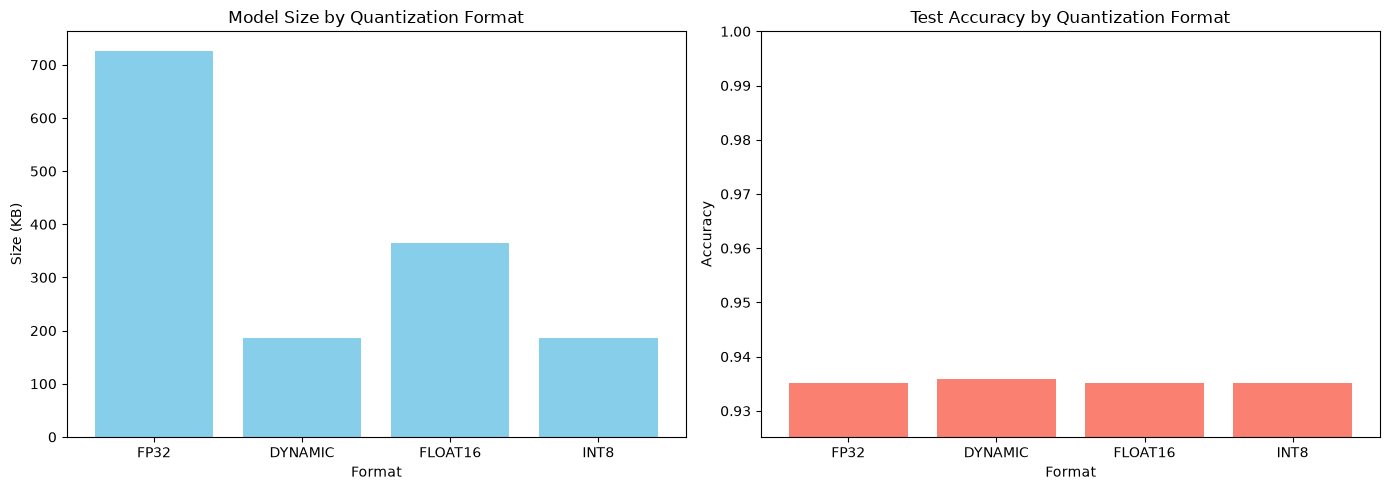

In [13]:
# Create one bar plot for model size and another for test accuracy.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(comparison_df['Format'], comparison_df['Model Size (KB)'], color='skyblue')
ax1.set_title('Model Size by Quantization Format')
ax1.set_ylabel('Size (KB)')
ax1.set_xlabel('Format')

ax2.bar(comparison_df['Format'], comparison_df['Test Accuracy'], color='salmon')
ax2.set_title('Test Accuracy by Quantization Format')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Format')
ax2.set_ylim([min(comparison_df['Test Accuracy']) - 0.01, 1.0])

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


Classification Report (INT8 Quantized Model):
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       496
           1       0.95      0.93      0.94       471
           2       0.94      0.94      0.94       420
           3       0.88      0.92      0.90       491
           4       0.90      0.88      0.89       532
           5       1.00      0.97      0.98       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



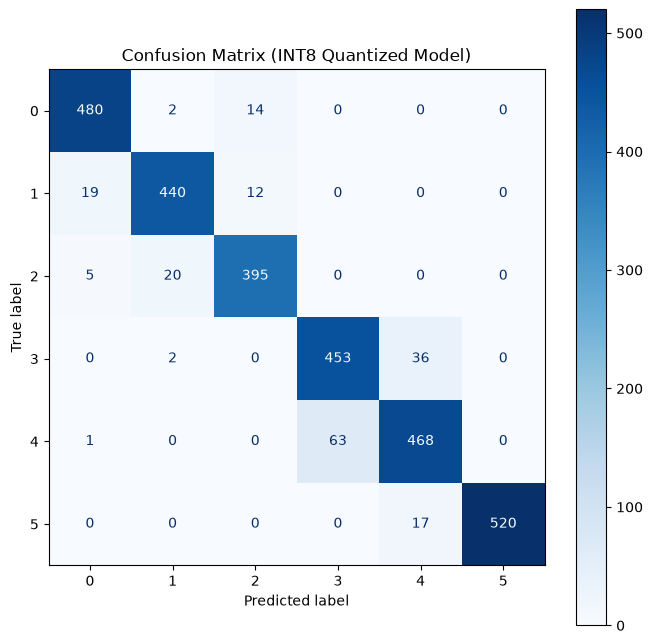

In [14]:
# 1. Load the saved INT8 model from disk
int8_model_path = OUTPUT_DIR / "mnist_model_int8.tflite"
int8_model_content = int8_model_path.read_bytes()

# 2. Evaluate model
_, y_pred_int8 = evaluate_tflite_model(int8_model_content, X_test, y_test)

# 3. Print the report
print("Classification Report (INT8 Quantized Model):")
print(classification_report(y_test, y_pred_int8))

# 4. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_int8)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix (INT8 Quantized Model)")
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

qat_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 561)]             0         
                                                                 
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                     

### Fine-Tune the QAT Model

In [16]:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

history_qat = qat_model.fit(
    X_train, 
    y_train, 
    validation_split=0.2, 
    epochs=8, 
    batch_size=64
)

Epoch 1/8
92/92 [==============================] - 2s 14ms/step - loss: 0.0334 - accuracy: 0.9891 - val_loss: 0.1298 - val_accuracy: 0.9517
Epoch 2/8
92/92 [==============================] - 1s 15ms/step - loss: 0.0296 - accuracy: 0.9905 - val_loss: 0.1384 - val_accuracy: 0.9490
Epoch 3/8
92/92 [==============================] - 1s 14ms/step - loss: 0.0293 - accuracy: 0.9903 - val_loss: 0.1302 - val_accuracy: 0.9524
Epoch 4/8
92/92 [==============================] - 2s 21ms/step - loss: 0.0260 - accuracy: 0.9903 - val_loss: 0.1329 - val_accuracy: 0.9517
Epoch 5/8
92/92 [==============================] - 2s 20ms/step - loss: 0.0249 - accuracy: 0.9915 - val_loss: 0.1640 - val_accuracy: 0.9463
Epoch 6/8
92/92 [==============================] - 2s 19ms/step - loss: 0.0267 - accuracy: 0.9891 - val_loss: 0.1567 - val_accuracy: 0.9490
Epoch 7/8
92/92 [==============================] - 1s 15ms/step - loss: 0.0249 - accuracy: 0.9913 - val_loss: 0.1413 - val_accuracy: 0.9517
Epoch 8/8
92/92 [===

### Evaluate the QAT Keras Model


In [17]:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_pred_probs = qat_model.predict(X_test)
y_pred_qat = np.argmax(qat_pred_probs, axis=1)

qat_test_accuracy = accuracy_score(y_test, y_pred_qat)
print(f"QAT Keras Test Accuracy: {qat_test_accuracy:.4f}")

print("\nClassification Report (QAT Keras Model):")
print(classification_report(y_test, y_pred_qat))

93/93 [==============================] - 0s 3ms/step
QAT Keras Test Accuracy: 0.9345

Classification Report (QAT Keras Model):
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       496
           1       0.94      0.90      0.92       471
           2       0.96      0.94      0.95       420
           3       0.96      0.87      0.91       491
           4       0.85      0.97      0.91       532
           5       1.00      0.95      0.97       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# Convert the QAT model to int8 TensorFlow Lite
qat_int8_model_content = convert_to_tflite_int8(qat_model)

# Define the file path
qat_int8_path = OUTPUT_DIR / "qat_model_int8.tflite"

# Save the model to disk and record its size in KB
qat_int8_size = save_binary_model(qat_int8_model_content, str(qat_int8_path))

# Evaluate the TFLite model on the test set
qat_int8_acc, y_pred_qat_int8 = evaluate_tflite_model(qat_int8_model_content, X_test, y_test)

# Print results
print(f"QAT INT8 Model saved to: {qat_int8_path}")
print(f"QAT INT8 Model Size: {qat_int8_size:.2f} KB")
print(f"QAT INT8 Test Accuracy: {qat_int8_acc:.4f}")

INFO:tensorflow:Assets written to: /tmp/tmp76ac3fc0/assets


INFO:tensorflow:Assets written to: /tmp/tmp76ac3fc0/assets


QAT INT8 Model saved to: pruning_outputs/qat_model_int8.tflite
QAT INT8 Model Size: 185.63 KB
QAT INT8 Test Accuracy: 0.9338


/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-14 21:24:05.545577: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 21:24:05.545642: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 21:24:05.545833: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp76ac3fc0
2026-07-14 21:24:05.548586: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 21:24:05.548603: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp76ac3fc0
2026-07-14 21:24:05.558847: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 21:24:05.667907: I tensorflow/cc/saved_model/loader

## 12. PTQ Int8 vs QAT Int8


In [19]:
# 1. Add the QAT INT8 results to the results list
results.append({
    "Model": "QAT INT8",
    "Size (KB)": qat_int8_size,
    "Accuracy": qat_int8_acc
})

# 2. Create the comparison DataFrame
comparison_df = pd.DataFrame(results)

# 3. Rename to match the requested output format
comparison_df = comparison_df.rename(columns={
    "Model": "Format",
    "Accuracy": "Test Accuracy",
    "Size (KB)": "Model Size (KB)"
})

# 4. Add the Model Family column
comparison_df.insert(0, "Model Family", "Baseline DNN")

# 5. Display the final comparison
print(comparison_df)

   Model Family    Format  Model Size (KB)  Test Accuracy
0  Baseline DNN      FP32       726.664062       0.935188
1  Baseline DNN   DYNAMIC       186.062500       0.935867
2  Baseline DNN   FLOAT16       365.625000       0.935188
3  Baseline DNN      INT8       185.281250       0.935188
4  Baseline DNN  QAT INT8       185.632812       0.933831


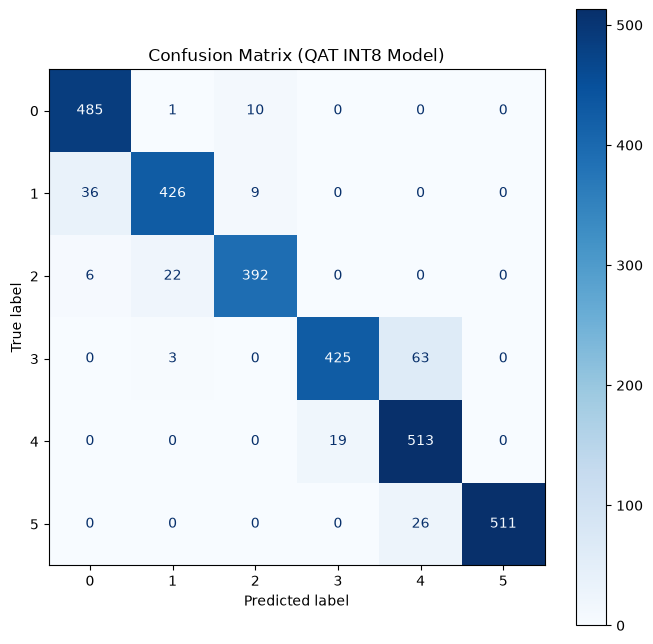

In [20]:
# Plot the confusion matrix for the QAT int8 model.

# Compute
cm_qat = confusion_matrix(y_test, y_pred_qat_int8)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat)
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title("Confusion Matrix (QAT INT8 Model)")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
